# Global Spatial Autocorrelation with Geary's C

This notebook covers global Geary's C  as an alternative to Moran's I for detecting spatial autocorrelation.

## Learning goals

By the end of this notebook, you will be able to:

- explain how Geary's $C$ measures spatial autocorrelation differently from Moran's $I$
- interpret the range and direction of Geary's $C$
- compute global Geary's $C$ and assess its significance via permutation inference


In [9]:
import geopandas as gpd
import libpysal as lps
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import esda

## Data preparation

We use the same Berlin neighbourhood data as the Moran's I notebooks, making it straightforward to compare results across statistics.

In [10]:
gdf = gpd.read_file("data/berlin-neighbourhoods.geojson")

In [11]:
bl_df = pd.read_csv("data/berlin-listings.csv")
geometry = gpd.points_from_xy(x=bl_df.longitude, y=bl_df.latitude, crs="epsg:4326")
bl_gdf = gpd.GeoDataFrame(bl_df, geometry=geometry)

In [12]:
bl_gdf["price"] = bl_gdf["price"].astype("float32")
sj_gdf = gpd.sjoin(
    gdf, bl_gdf, how="inner", predicate="intersects", lsuffix="left", rsuffix="right"
)
median_price_gb = sj_gdf["price"].groupby([sj_gdf["neighbourhood_group"]]).mean()
gdf = gdf.join(median_price_gb, on="neighbourhood_group")
gdf.rename(columns={"price": "median_pri"}, inplace=True)
gdf["median_pri"] = gdf["median_pri"].fillna(gdf["median_pri"].mean())

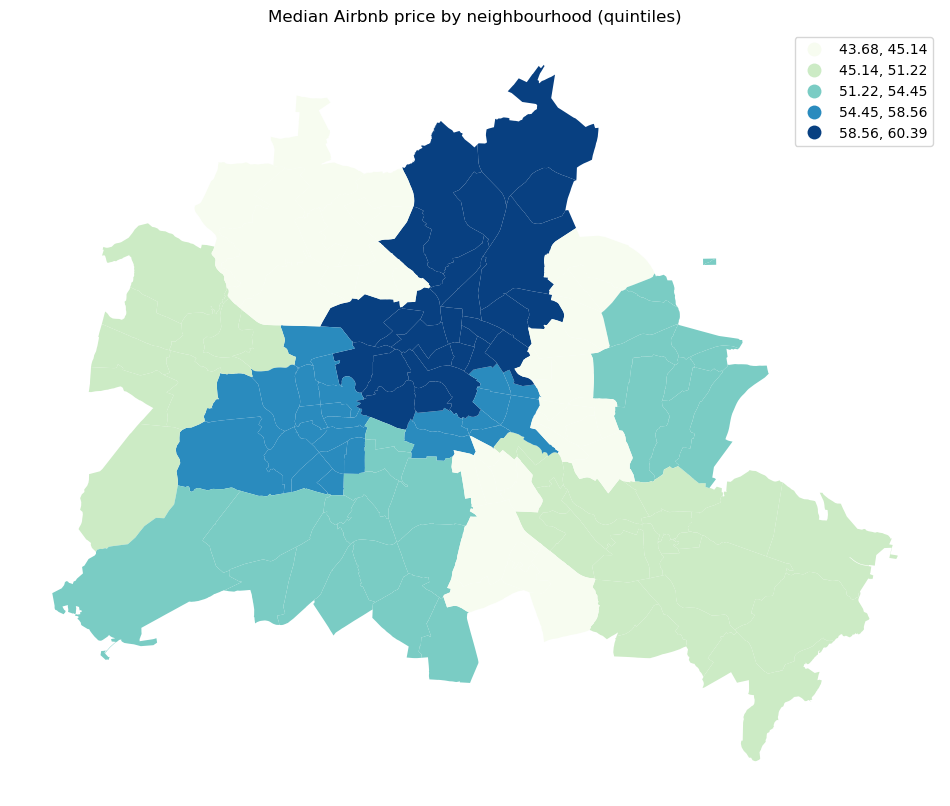

In [13]:
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"aspect": "equal"})
gdf.plot(column="median_pri", scheme="Quantiles", k=5, cmap="GnBu", legend=True, ax=ax)
ax.set_axis_off()
ax.set_title("Median Airbnb price by neighbourhood (quintiles)")
plt.show()

## Geary's C

[Moran's I](global_morans_i.ipynb#computing-global-morans-i) measures spatial autocorrelation through the *cross-product* of mean-centered values: it is large when values above (or below) the mean cluster together. Geary's $C$ instead measures autocorrelation through the *squared difference* between neighbouring pairs:

$$C = \frac{(n-1)}{2S_0} \frac{\sum_{i=1}^{n} \sum_{j=1}^{n} w_{ij}(x_i - x_j)^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$

where $x_i$ is the value for the variable $x$ at location $i$ of $n$ locations, and $w_{ij}$ is the spatial weight expressing the neighbor relationship between locations $i$ and $j$, and $S_0$ is the sum of all weights ($S_0 = \sum_i \sum_j w_{ij}$).

Because $C$ works with squared differences rather than mean-centered deviations, it is more sensitive to *local* variations between neighbours, whereas Moran's $I$ is a better overall summary of global spatial structure. 

The expected value of $C$ under the null hypothesis of no spatial association is:

$$E[C] = 1$$

**Interpreting $C$:**

| Value | Meaning |
|---|---|
| $C \approx 1$ | No spatial autocorrelation (null hypothesis) |
| $C < 1$ | Positive spatial autocorrelation (similar values cluster together) |
| $C > 1$ | Negative spatial autocorrelation (dissimilar values tend to be neighbours) |

The two statistics are inversely related: evidence of positive autocorrelation under Moran's $I$ ($I > E[I]$) corresponds to $C < 1$.

## Global Geary's C

We begin by building row-standardised Queen contiguity weights and computing the global statistic. The global statistic $C$ answers: *is there a statistically significant overall concentration of similar or dissimilar adjacent values?*

In [17]:
df = gdf
wq = lps.weights.Queen.from_dataframe(df, use_index=False, silence_warnings=True)
wq.transform = "r"
y = df["median_pri"]

np.random.seed(12345)
gc = esda.Geary(y, wq)
print(f"Observed C:   {gc.C:.4f}")
print(f"Expected C:   {gc.EC:.4f}")

Observed C:   0.3401
Expected C:   1.0000


## Inference

Inference about $C$ uses the same general framework underlying [Moran's I](global_morans_i.ipynb#inference), where the reference distribution can be based on analytical reasoning or permutation based.

To derive the analytical expected value and variance for statistical inference, we define structural constants based on the weights matrix $W$:

* $S_0 = \sum_{i=1}^n \sum_{j=1}^n w_{ij}$ (The sum of all spatial weights)
* $S_1 = \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n (w_{ij} + w_{ji})^2$
* $S_2 = \sum_{i=1}^n \left( \sum_{j=1}^n w_{ij} + \sum_{j=1}^n w_{ji} \right)^2$

We also rely on the sample moments of the attribute vector $x$, specifically the sample kurtosis coefficient $k$.

---

### Free Sampling (The Normality Assumption)

#### Expected Value
The expected value of $C$ under free sampling remains independent of the empirical values of $x$:

$$E_N(C) = 1$$

#### Variance
The mathematical variance under the normality assumption is structured as follows:

$$Var_N(C) = \frac{2S_1 + S_2}{4S_0^2} \cdot \frac{n-1}{n+1}$$

---

### Non-Free Sampling (The Randomization Assumption)

#### Expected Value
Because the expectation across all permutations averages out the spatial structure, the expected value under randomization is identical to the free sampling expectation:

$$E_R(C) = 1$$

#### Variance
The variance under randomization must account for the exact empirical distribution of the data by incorporating the sample kurtosis $k$:

$$Var_R(C) = \frac{(n-1)S_1(n^2 - 3n + 3 - (n-1)k)}{n(n-2)(n-3)S_0^2} - \frac{(n-1)S_2(n^2 - n + 2 - 2(n-1)k)}{4n(n-2)(n-3)S_0^2} + \frac{S_0^2(n^2 - 3 - (n-1)^2k)}{n(n-2)(n-3)S_0^2}$$

---

### Asymptotic Inference (Z-score)

For practical execution, these analytical moments are translated into an asymptotic standard normal $Z$-score:

$$Z(C) = \frac{C - E(C)}{\sqrt{Var(C)}}$$

* **Negative $Z(C)$:** Indicates a spatial cluster of **similar values** (positive spatial autocorrelation).
* **Positive $Z(C)$:** Indicates a spatial cluster of **dissimilar values** (negative spatial autocorrelation).

While computationally fast, the analytical approach relies on asymptotic assumptions which may not hold for small sample sizes or highly skewed data.

In [18]:
print(f"z-score (norm):   {gc.z_norm:.4f}")
print(f"p-value (norm):   {gc.p_norm:.4f}")

z-score (norm):   -11.5769
p-value (norm):   0.0000


### Permutation-based inference

As with [Moran's $I$](global_morans_i.ipynb#permutation-based-inference), we can also assess the observed $C$ against a reference distribution generated by randomly permuting attribute values while holding the spatial structure fixed.

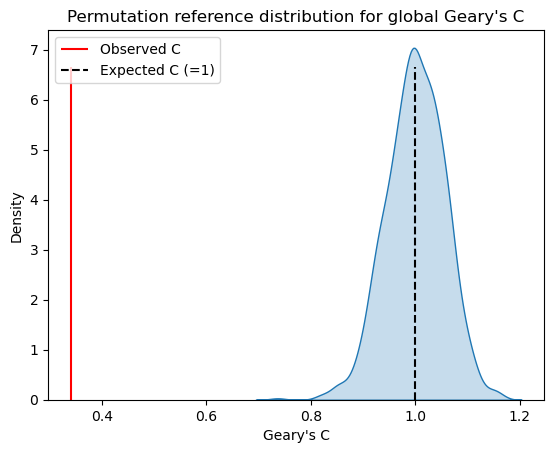

p-value (sim):    0.0010


In [19]:
import seaborn as sns

sns.kdeplot(gc.sim, fill=True)
plt.vlines(gc.C, 0, plt.gca().get_ylim()[1] * 0.9, color="r", label="Observed C")
plt.vlines(
    gc.EC,
    0,
    plt.gca().get_ylim()[1] * 0.9,
    color="k",
    linestyle="--",
    label="Expected C (=1)",
)
plt.xlabel("Geary's C")
plt.legend()
plt.title("Permutation reference distribution for global Geary's C")
plt.show()

print(f"p-value (sim):    {gc.p_sim:.4f}")

## Comparing Geary's C and Moran's I

Both statistics detect the same broad spatial structure, but they are not identical:

- **Moran's I** compares each observation to the *global mean*; it is more sensitive to broad trends.
- **Geary's C** compares each observation directly to its *neighbours*; it is more sensitive to local differences.

When the two disagree, it usually indicates that a local cluster or outlier is driven by a very local contrast rather than a deviation from the global level.

For most applied work Moran's I is the first choice; Geary's C and its local form add value when you specifically want to emphasize *pair-wise dissimilarity* between neighbours rather than global clustering.

## Takeaways

- Global Geary's $C$ is centred at 1 under the null; values below 1 indicate positive autocorrelation.
- Geary's $C$ is based on squared differences between neighbours, making it sensitive to local contrasts.
- Permutation inference is preferred over the normality assumption for small samples or non-normal data.
- Geary and Moran are complementary: using both gives a fuller picture of spatial structure.